In [1]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import netket as nk
import netket.experimental as nkx
import sys
sys.path.append('..')
from NES_VMC import NESTotalAnsatz, create_machine,\
    SingleStateAnsatz,create_single_machine,\
    create_machine_matrix,Ham_psi,Ham_Psi,NES_loss_energy,nes_vmc_gradient,\
    NESFermionHopRule,compute_qgt,sampler_info,\
    create_machine_matrix_stable,create_single_machine_gauge_fixed,create_machine_max_stable,\
    NESTotalAnsatz_stable,create_machine_stable,NES_loss_energy_stable,nes_vmc_gradient_stable,\
    make_grad_fn,make_qgt_fn
import optax
from scipy.sparse.linalg import eigsh
from typing import Callable
from functools import partial
from jax.flatten_util import ravel_pytree
import time
import itertools
from pyscf import gto, scf, fci
import numpy as np



jnp.set_printoptions(
    linewidth=9999,
    threshold=jnp.inf,
    precision=8,
    suppress=False,
)


/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can load logged data with nk.utils.history.HistoryDict.from_file(data.log).

In [2]:
from LiH import SINGLE_SIZE,ha,hi,hi_ext,ext_edges,single_edges_full,K,Hatree_Fock

LiH 分子基本信息
HF energy = -7.86245187 Ha
Total electrons = (2, 2)
Total basis functions = 6

Total orbitals in STO-3G: 6

LiH / STO-3G 基准能量
E0 = -7.88259092 Ha | excitation = 0.0000 eV
E1 = -7.76563664 Ha | excitation = 3.1825 eV
E2 = -7.74858736 Ha | excitation = 3.6464 eV
E3 = -7.71601970 Ha | excitation = 4.5326 eV
E4 = -7.71601970 Ha | excitation = 4.5326 eV
E5 = -7.69619638 Ha | excitation = 5.0721 eV

Active Space Configuration:
  n_orbitals = 4
  n_alpha = 2, n_beta = 2
  Total electrons = (2, 2)

Hilbert 信息
K = 4
hi.size = 8
hi_ext.size = 32
SINGLE_SIZE = 8
target_loss = sum(E_fcis[:K]) = -31.11283462

HF reference state: [0 0 1 1 0 0 1 1]
Alpha orbitals: [0, 1, 2, 3]... (4 total)
Beta orbitals: [4, 5, 6, 7]... (4 total)

Single edges (total): 12


In [3]:
import logging
# 日志配置
logger = logging.getLogger('NES_VMC_K4')
logger.setLevel(logging.INFO)
# 阻止日志向上传播
logger.propagate = False
# 清除所有旧handler，防止重复打印
logger.handlers.clear()

# 自定义日志格式：只打印内容，不带等级、logger名
simple_formatter = logging.Formatter("%(message)s", datefmt="%H:%M:%S")

# 1. 文件输出处理器
file_handler = logging.FileHandler("0710_K4_LiH_规范漂移.log", mode="w", encoding="utf-8")
file_handler.setFormatter(simple_formatter)
file_handler.setLevel(logging.INFO)
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(simple_formatter)
console_handler.setLevel(logging.INFO)
logger.addHandler(console_handler)

print('库导入完成')

库导入完成


In [4]:

nes_rule = NESFermionHopRule(
    edges=ext_edges,
    K=K,
    single_size=SINGLE_SIZE,
)

In [ ]:
Hatree_Fock

In [5]:
import time
import jax
import jax.numpy as jnp
import optax
from NES_VMC import compute_qgt_fixed,\
    create_single_machine_gauge_fixed,NESTotalAnsatz_gauge_stable,create_machine_gauge_stable,\
        create_machine_matrix_gauge_stable,create_machine_max_gauge_stable

# ====================== 超参统一配置 ======================
N_CHAINS = 16
N_WARMUP = 200
N_SAMPLES_PER_CHAIN = 200
SWEEP_SIZE = 30
N_ITER = 500
SINGLE_SIZE = hi.size  # 单个子系统维度 = 4
Natural_Grad = True
clip_norm = 20.0        # 全局梯度L2上限，QML推荐1~2
lr = 0.1
qgt_diag_shift = 0.1  # 上调正则，抑制QGT梯度爆炸

# ====================== 模型初始化 ======================
from NES_VMC import (
    NESTotalAnsatz_stable,
    create_gauge_fixed_total_machines,
    create_single_machine_gauge_fixed,
    make_grad_fn,
    make_qgt_fn,
    create_machine_gauge_synthesis,
    create_single_machine_gauge_fixed,
)

# ====================== 模型初始化 ======================

total_ansatz = NESTotalAnsatz_gauge_stable(SINGLE_SIZE, K, 
                                           SINGLE_SIZE+K, ref_state=Hatree_Fock,
                                           rngs=nnx.Rngs(11))

total_machine_log_Psi_gauge, graphdef, total_params =  create_machine_gauge_stable(total_ansatz)
#total_params = history['params'][-1]

total_machine_log_Psi_gauge, \
total_machine_L_stable, \
total_machine_shift, \
total_machine_L_gauge = create_machine_gauge_synthesis(total_ansatz)


single_machine_list = []
for ansatz in total_ansatz.single_ansatz_list:
    m, _, _ = create_single_machine_gauge_fixed(ansatz,Hatree_Fock)
    single_machine_list.append(m)  
    
    
    
grad_fn = make_grad_fn(
    ha,
    total_machine_L_stable,
    total_machine_shift,
    total_machine_log_Psi_gauge,
    single_machine_list,
)
qgt_fn = make_qgt_fn(total_machine_log_Psi_gauge)

nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=N_CHAINS,
    sweep_size=SWEEP_SIZE
)


eigvals, eigvecs = eigsh(ha.to_sparse(), k=K, which="SA", tol=1e-10)
# ====================== 优化器：梯度裁剪 + SGD ======================
# chain顺序：先裁剪梯度，再SGD更新
optimizer = optax.chain(
    optax.clip_by_global_norm(clip_norm),
    optax.sgd(learning_rate=lr)
)
opt_state = optimizer.init(total_params)


sampler_rng = jax.random.PRNGKey(21)
sampler_state = nes_sampler.init_state(total_machine_log_Psi_gauge, total_params, sampler_rng)

# ====================== 训练历史（新增Ψ矩阵条件数监控） ======================
history = {
    'step': [],
    'energy_0st': [],
    'energy_1st': [],
    'energy_2st': [],
    'energy_3st': [],
    'loss': [],
    'params': [],
    'E_Lmatrix': [],
    'samples': [],
    'log_Psi_mean': [],
    'log_Psi_min': [],
    'log_Psi_max': [],
    'grad_norm_raw': [],       # QGT前原始梯度
    'grad_norm_natural': [],   # QGT自然梯度（裁剪前）
    'grad_norm_clipped': [],   # 裁剪后真实梯度（≤clip_norm）
    'psi_cond': [],           # 新增：波函数矩阵条件数
}

logger.info("\n" + "="*60)
logger.info(f"开始多链 NES-VMC 训练 | 使用{'自然' if Natural_Grad else '原始'}梯度")
logger.info("="*60)
logger.info(f"精确CAS基准：基态={eigvals[0]:.8f} Ha | 1激发={eigvals[1]:.8f} Ha|2激发={eigvals[2]:.8f} Ha|3激发={eigvals[3]:.8f} Ha|")
logger.info(f"理论 Loss 上限：{sum(eigvals[0:K]):.8f} ")
logger.info(f"超参：clip_norm={clip_norm}, lr={lr}, QGT diag_shift={qgt_diag_shift}")

start_time = time.time()
for step in range(N_ITER):
    # 采样
    samples_raw, sampler_state = nes_sampler.sample(
        machine=total_machine_log_Psi_gauge,
        parameters=total_params,
        state=sampler_state,
        chain_length=N_SAMPLES_PER_CHAIN
    )
    samples = samples_raw.reshape(-1, hi_ext.size)
    x_batch = samples.reshape(-1, K, SINGLE_SIZE)
    
    grad_raw, loss_mean, E_L_mean, aux = grad_fn(total_params, x_batch)
    
    grad_raw_flat, unravel_fn = ravel_pytree(grad_raw)
    grad_norm_raw = jnp.linalg.norm(grad_raw_flat)
    grad_update = grad_raw

    # ========== 异常提前拦截，防止崩溃卡死 ==========
    has_nan_grad = jnp.any(jnp.isnan(grad_raw_flat))
    grad_explode = grad_norm_raw > 5000.0
    if has_nan_grad or grad_explode:
        logger.warning(f"【Step {step} 告警】梯度异常！nan={has_nan_grad}, raw_grad_norm={grad_norm_raw:.2f}")

    # 2. QGT自然梯度预条件
    if Natural_Grad:        
        qgt_reg_mat = qgt_fn(total_params, x_batch, qgt_diag_shift)
        ng_flat = jnp.linalg.solve(qgt_reg_mat, grad_raw_flat)
        

        grad_update = unravel_fn(ng_flat)
        grad_norm_natural = jnp.linalg.norm(ng_flat)
    else:
        grad_norm_natural = grad_norm_raw

    # 3. 梯度裁剪（optimizer.update内部自动执行）
    updates, opt_state = optimizer.update(grad_update, opt_state, total_params)
    # 单独计算裁剪后梯度范数用于监控
    clip_transform = optax.clip_by_global_norm(clip_norm)
    clipped_grad, _ = clip_transform.update(grad_update, opt_state[0], total_params)
    clipped_flat, _ = ravel_pytree(clipped_grad)
    grad_norm_clipped = jnp.linalg.norm(clipped_flat)
    
    # 如果梯度范数为0 则结束迭代
    if grad_norm_clipped == 0.0:
        logger.info(f"【Step {step} 告警】梯度范数为0，结束迭代")
        break

    history['params'].append(total_params)
    #ref_state_value = total_machine(total_params, Hatree_Fock)
    # 参数更新
    total_params = optax.apply_updates(total_params, updates)

    # ====================== 新增：计算Ψ矩阵条件数 ======================
    # 取单批次样本计算波函数矩阵，用第一组组态做代表
    x_single = x_batch[0:1, ...]
    psi_mat = total_machine_L_stable(total_params, x_single)[0]  # 取出N×N波函数矩阵
    psi_cond = jnp.linalg.cond(psi_mat)

    # 波函数标量输出
    log_Psi_batch = total_machine_log_Psi_gauge(total_params, x_batch)
    #eig_vals, eig_vecs = jnp.linalg.eig(E_L_mean)
    
    
    eig_vals, eig_vecs = jnp.linalg.eig(E_L_mean)
    sort_idx = jnp.argsort(eig_vals.real)
    eig_vals, eig_vecs = eig_vals[sort_idx], eig_vecs[:, sort_idx]

    
    # 记录历史
    history['step'].append(step)
    history['loss'].append(loss_mean)
    history['E_Lmatrix'].append(E_L_mean)
    history['samples'].append(samples)
    history['log_Psi_mean'].append(log_Psi_batch.mean())
    history['log_Psi_min'].append(log_Psi_batch.min())
    history['log_Psi_max'].append(log_Psi_batch.max())
    history['energy_0st'].append(eig_vals[0])
    history['energy_1st'].append(eig_vals[1])
    history['energy_2st'].append(eig_vals[2])
    history['energy_3st'].append(eig_vals[3])
    
    history['grad_norm_raw'].append(grad_norm_raw)
    history['grad_norm_natural'].append(grad_norm_natural)
    history['grad_norm_clipped'].append(grad_norm_clipped)
    history['psi_cond'].append(psi_cond)  # 保存条件数

    # 打印日志，新增Ψ条件数输出
    if step % 1 == 0 or step == N_ITER - 1:
        logger.info(f"[Step {step:3d}] logΨ: mean={log_Psi_batch.mean():.3f} | min={log_Psi_batch.min():.3f} | max={log_Psi_batch.max():.3f}")
        logger.info(f"梯度监控 | raw={grad_norm_raw:.4f} | natural={grad_norm_natural:.4f} | clipped={grad_norm_clipped:.4f}(上限{clip_norm})")
        logger.info(f"Ψ矩阵条件数 cond(Ψ) = {psi_cond:.2e}")
        logger.info(f"Loss={loss_mean:.6f} | E0={eig_vals[0]:.8f} | E1={eig_vals[1]:.8f}|E2={eig_vals[2]:.8f}|E3={eig_vals[3]:.8f}")
        logger.info("#-----------------------------------------#")

end_time = time.time()
print(f"训练耗时：{end_time - start_time:.2f} 秒")
print("\n" + "="*60)
print("训练完成!")
print("="*60)

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(

开始多链 NES-VMC 训练 | 使用自然梯度
精确CAS基准：基态=-7.86364558 Ha | 1激发=-7.72153670 Ha|2激发=-7.70823970 Ha|3激发=-7.68581513 Ha|
理论 Loss 上限：-30.97923710 
超参：clip_norm=20.0, lr=0.1, QGT diag_shift=0.1
[Step   0] logΨ: mean=9.264+0.151j | min=3.413-2.258j | max=11.034+0.951j
梯度监控 | raw=20.1724 | natural=2.4716 | clipped=2.4716(上限20.0)
Ψ矩阵条件数 cond(Ψ) = 1.15e+01
Loss=-21.989180 | E0=-5.90164375+0.01112455j | E1=-5.64291525+0.01155537j|E2=-5.33633137-0.02197868j|E3=-5.10828400-0.00074594j
#-----------------------------------------#
[Step   1] logΨ: mean=10.157+0.006j | min=4.232+2.681j | max=11.978+0.750j
梯度监控 | raw=18.2644 | natural=2.2214 | clipped=2.2214(上限20.0)
Ψ矩阵条件数 cond(Ψ) = 2.24e+01
Loss

KeyboardInterrupt: 

In [6]:
import pickle
with open('./data/0710_LiH_K4_规范漂移.pkl', 'wb') as f:
    pickle.dump(history,f)

In [ ]:
import pickle
with open('./data/0708_LiH_K4_规范漂移.pkl', 'rb') as f:
    history = pickle.load(f)


/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


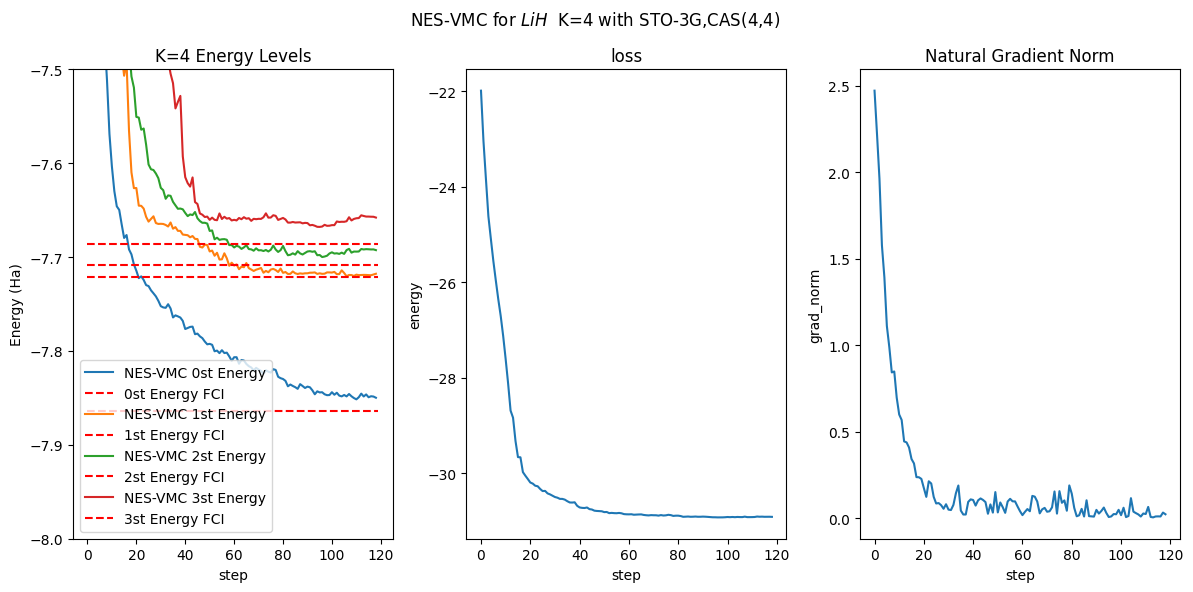

In [7]:
import matplotlib.pyplot as plt

# 创建 2行1列 的子图
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
fig.suptitle('NES-VMC for $LiH$  K=4 with STO-3G,CAS(4,4)')



# 第一个子图
axs[0].plot(history['energy_0st'],label='NES-VMC 0st Energy')
axs[0].hlines(eigvals[0],0,len(history['energy_0st']),linestyle='--',color='red',label='0st Energy FCI')
axs[0].plot(history['energy_1st'],label='NES-VMC 1st Energy')
axs[0].hlines(eigvals[1],0,len(history['energy_1st']),linestyle='--',color='red',label='1st Energy FCI')
axs[0].plot(history['energy_2st'],label='NES-VMC 2st Energy')   
axs[0].hlines(eigvals[2],0,len(history['energy_2st'][:200]),linestyle='--',color='red',label='2st Energy FCI')
axs[0].plot(history['energy_3st'],label='NES-VMC 3st Energy')
axs[0].hlines(eigvals[3],0,len(history['energy_3st'][:200]),linestyle='--',color='red',label='3st Energy FCI')
axs[0].set_ylim(-8, -7.5)
axs[0].set_title('K=4 Energy Levels')
axs[0].set_ylabel('Energy (Ha)')
axs[0].set_xlabel('step')
axs[0].legend()



# 第二个子图
axs[1].plot(history['loss'])
axs[1].set_title('loss')
axs[1].set_xlabel('step')
axs[1].set_ylabel('energy')

# 第三个子图
axs[2].plot(history['grad_norm_natural'])
axs[2].set_title('Natural Gradient Norm')
axs[2].set_xlabel('step')
axs[2].set_ylabel('grad_norm')

plt.tight_layout()  # 自动调整间距
plt.show()